In [21]:
import os
import time
import copy
import glob
import cv2
import shutil

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [22]:
# 오류로 인해 data -> catanddog_train이라는 파일명으로 새로 복사함

source_path = '/content/drive/MyDrive/Colab Notebooks/9기 유런/chap05/data/catanddog'
destination_path = '/content/catanddog_train'

# Check if the source path exists
if os.path.exists(source_path):
    # Check if the destination path exists, if not, create it
    if not os.path.exists(destination_path):
        os.makedirs(destination_path)

    # Copy the contents of the source directory to the destination directory
    # Use copytree for directories
    shutil.copytree(source_path, destination_path, dirs_exist_ok=True)
    print(f"Successfully copied data from {source_path} to {destination_path}")
else:
    print(f"Source path not found: {source_path}")

Successfully copied data from /content/drive/MyDrive/Colab Notebooks/9기 유런/chap05/data/catanddog to /content/catanddog_train


In [23]:
# 문제가 되는 dir 삭제(.ipynb_checkpoints)

problematic_dir = '/content/catanddog_train/.ipynb_checkpoints'
if os.path.exists(problematic_dir):
    shutil.rmtree(problematic_dir)
    print(f"Removed problematic directory: {problematic_dir}")
else:
    print(f"Problematic directory not found: {problematic_dir}")

Removed problematic directory: /content/catanddog_train/.ipynb_checkpoints


In [24]:
data_path = '/content/catanddog_train/train'
transform = transforms.Compose([
    transforms.Resize([256, 256]),
    transforms. RandomResizedCrop(224),
    transforms. RandomHorizontalFlip(),
    transforms. ToTensor()
])
train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform=transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8,
    shuffle=True
)

print(len(train_dataset))

385


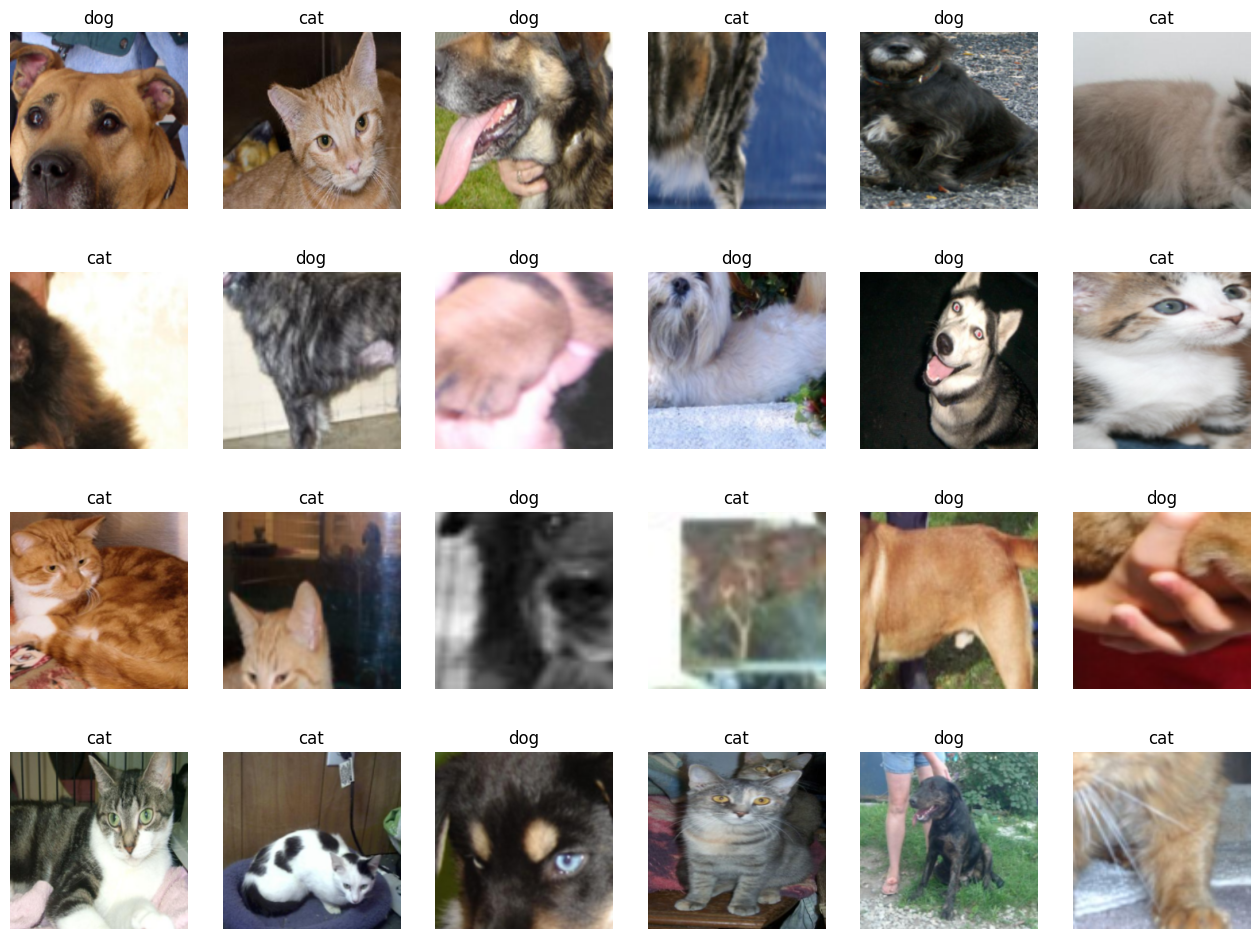

In [25]:
# numpy 임포트 코드 추가
import numpy as np

samples, labels = next(iter(train_loader)) # ,next() 사용 불가
classes = {0:'cat', 1:'dog'}
fig = plt.figure(figsize=(16,24))
for i in range (24):
  a = fig.add_subplot(4,6,i+1)
  a.set_title(classes[labels[i].item()])
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(), (1,2,0)))
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

In [26]:
resnet18 = models.resnet18(pretrained=True)

In [27]:
def set_parameter_requires_grad(model, feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      param.requires_grad = False

set_parameter_requires_grad(resnet18)

In [28]:
resnet18.fc = nn.Linear(512, 2)

In [29]:
for name, param in resnet18.named_parameters():
  if param.requires_grad:
    print(name, param.data)

fc.weight tensor([[-0.0036, -0.0033, -0.0132,  ...,  0.0327, -0.0014,  0.0408],
        [ 0.0219, -0.0241, -0.0285,  ..., -0.0382, -0.0284, -0.0382]])
fc.bias tensor([-0.0018, -0.0430])


In [30]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
  param.requires_grad = False

model.fc = torch.nn. Linear(512, 2)
for param in model.fc.parameters():
  param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn. CrossEntropyLoss()
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [31]:
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13,is_train=True):
  since = time.time()
  acc_history = [ ]
  loss_history = [ ]
  best_acc = 0.0

  for epoch in range(num_epochs): # 에포크만큼 반복
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-' * 10)
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloaders: # 데이터로더에 전달된 데이터만큼 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      model.to(device)
      optimizer.zero_grad() # 기울기를 0으로 설정
      outputs = model(inputs) # 순전파 학습
      loss = criterion(outputs, labels)
      _, preds = torch.max(outputs, 1)
      loss.backward() # 역전파 학습
      optimizer.step()

      running_loss += loss.item() * inputs.size(0)
      running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloaders.dataset) # 평균 오차 계산
    epoch_acc = running_corrects.double() / len(dataloaders.dataset) # 평균 정확도 계산

    print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    loss_history.append(epoch_loss)
    torch.save(model.state_dict(), os.path.join('/content/catanddog_train','{0:0=2d}.pth'.format(epoch)))
    print()


  time_elapsed = time.time() - since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60,time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))
  return acc_history, loss_history

In [32]:
# 파라미터 학습 결과를 옵티마이저에 전달
params_to_update = [ ]
for name, param in resnet18.named_parameters():
  if param.requires_grad == True:
    params_to_update.append (param)
    print("\t", name)

optimizer = optim. Adam(params_to_update)

	 fc.weight
	 fc.bias


In [ ]:
# 모델 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------
Loss: 0.5614 Acc: 0.7065

Epoch 1/12
----------
Loss: 0.4098 Acc: 0.8182

Epoch 2/12
----------
Loss: 0.3438 Acc: 0.8442

Epoch 3/12
----------
Loss: 0.3122 Acc: 0.8571

Epoch 4/12
----------
Loss: 0.2475 Acc: 0.9143

Epoch 5/12
----------
Loss: 0.2626 Acc: 0.8935

Epoch 6/12
----------
Loss: 0.2474 Acc: 0.9065

Epoch 7/12
----------
Loss: 0.2519 Acc: 0.8883

Epoch 8/12
----------
Loss: 0.1873 Acc: 0.9247

Epoch 9/12
----------
Loss: 0.2005 Acc: 0.9195

Epoch 10/12
----------
Loss: 0.1968 Acc: 0.9273

Epoch 11/12
----------
Loss: 0.1976 Acc: 0.9117

Epoch 12/12
----------
Loss: 0.1924 Acc: 0.9221

Training complete in 8m 39s
Best Acc: 0.927273


In [ ]:
# 테스트 데이터 호출 및 전처리

test_path = '/content/catanddog_train/test'
transform = transforms.Compose([
  transforms.Resize(224),
  transforms.CenterCrop(224),
  transforms. ToTensor(),
])
test_dataset = torchvision.datasets. ImageFolder(
  root=test_path,
  transform=transform
)
test_loader = torch.utils.data.DataLoader(
  test_dataset,
  batch_size=32,
  num_workers=1,
  shuffle=True
)

print(len(test_dataset))

98


In [ ]:
def eval_model(model, dataloaders, device):
  since = time.time()
  acc_history = [ ]
  best_acc = 0.0

  saved_models = glob.glob('/content/catanddog_train/' + '*.pth')
  # glob = 현재 디렉터리에서 원하는 파일만 추출하여 가져옴, .pth 확장자 파일만 가져옴
  saved_models.sort()
  print('saved_model', saved_models)

  for model_path in saved_models: # 모델 재사용
    print('Loading model', model_path)

    model.load_state_dict(torch.load(model_path))
    model.eval()
    model.to(device)
    running_corrects = 0

    for inputs, labels in dataloaders: # 테스트 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.no_grad(): # autograd를 사용하지 않겠다는 의미
        outputs = model (inputs) # 데이터를 모델에 적용한 결과를 outputs에 저장

      _, preds = torch.max(outputs.data, 1)
      # preds [preds >= 0.5] = 1 # torch.max로 출력된 값이 0.5보다 크면 올바르게 예측 - This logic is incorrect for torch.max output
      # preds [preds <0.5] = 0 # torch.max로 출력된 값이 0.5보다 작으면 틀리게 예측 - This logic is incorrect for torch.max output
      # torch.max returns the index of the max value, which is already the class prediction (0 or 1)
      running_corrects += torch.sum(preds == labels.data)

    epoch_acc = running_corrects.double() / len(dataloaders.dataset)
    print('Acc: {:.4f}'.format(epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc
    acc_history.append(epoch_acc.item()) # Append accuracy for every epoch
    print()

  time_elapsed = time.time() - since
  print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))

  return acc_history

In [16]:
# 테스트 데이터 평가 함수에 적용
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['/content/catanddog_train/00.pth', '/content/catanddog_train/01.pth', '/content/catanddog_train/02.pth', '/content/catanddog_train/03.pth', '/content/catanddog_train/04.pth', '/content/catanddog_train/05.pth', '/content/catanddog_train/06.pth', '/content/catanddog_train/07.pth', '/content/catanddog_train/08.pth', '/content/catanddog_train/09.pth', '/content/catanddog_train/10.pth', '/content/catanddog_train/11.pth', '/content/catanddog_train/12.pth']
Loading model /content/catanddog_train/00.pth
Acc: 0.8878

Loading model /content/catanddog_train/01.pth
Acc: 0.9082

Loading model /content/catanddog_train/02.pth
Acc: 0.9184

Loading model /content/catanddog_train/03.pth
Acc: 0.9388

Loading model /content/catanddog_train/04.pth
Acc: 0.9286

Loading model /content/catanddog_train/05.pth
Acc: 0.9592

Loading model /content/catanddog_train/06.pth
Acc: 0.9388

Loading model /content/catanddog_train/07.pth
Acc: 0.9388

Loading model /content/catanddog_train/08.pth
Acc: 0.9592

L

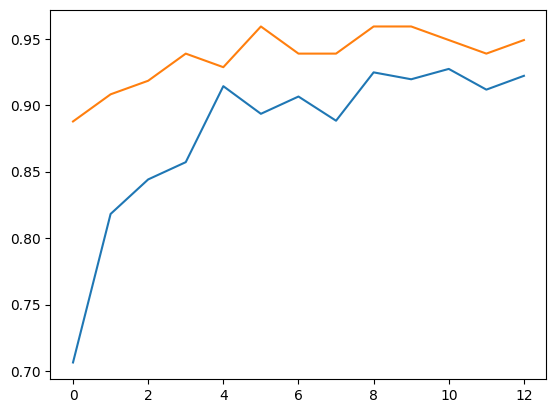

In [17]:
# 훈련과 테스트 데이터 정확도 그래프로 확인
# 223p만큼 우상향 추세를 보이지 않지만, 어쨌든 우상향임
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

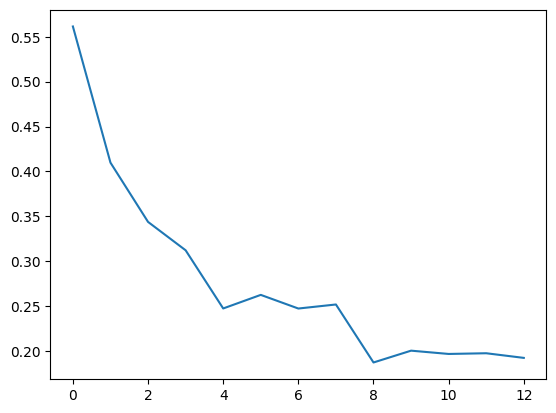

In [18]:
# 다소 오차가 적은 편(224p에 비해)
plt.plot(train_loss_hist)
plt.show()

In [19]:
def im_convert(tensor):
  image = tensor.clone().detach().numpy()
  image = image.transpose(1, 2,0)
  image = image * (np.array((0.5,0.5,0.5)) + np.array((0.5,0.5,0.5)))
  image = image.clip(0, 1)
  return image

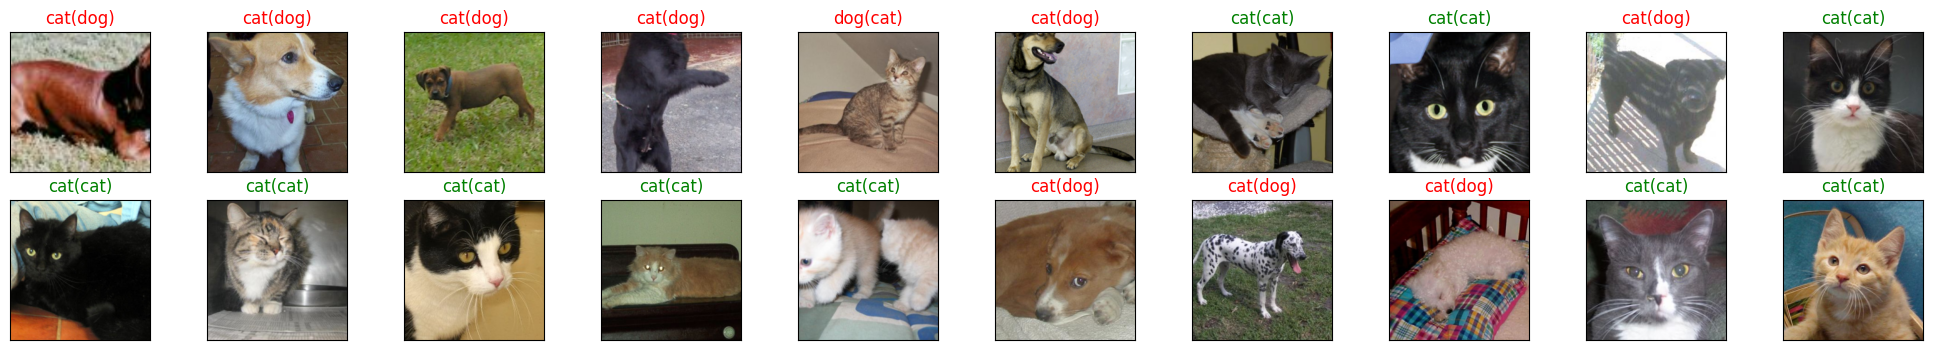

<Figure size 640x480 with 0 Axes>

In [20]:
# 전처리한 이미지로 예측 결과 출력
classes = {0:'cat', 1:'dog'}

dataiter = iter(test_loader)
images, labels = next(dataiter)
# .next() 대신 next() 사용
# 테스트 데이터셋에서 이미지와 레이블을 분리
output = model(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25,4))
for idx in np.arange(20):
  ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
  plt.imshow(im_convert(images[idx]))
  a.set_title(classes[labels[i].item()])
  ax.set_title("{}({})".format(str(classes[preds[idx].item()]), str(classes[labels[idx].item()])), color=("green" if preds[idx]==labels[idx] else "red"))

plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0) # 서브플롯에서 위치 조정

In [34]:
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import ToTensor
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

device = torch. device("cuda" if torch.cuda.is_available() else "cpu")

In [43]:
class XAI(torch.nn. Module):
  def __init__(self, num_classes=2):
    super(XAI, self).__init__()
    self.features = nn. Sequential(
      nn.Conv2d(3, 64, kernel_size=3, bias=False),
      nn.BatchNorm2d(64),
      nn.ReLU(inplace=True),
      nn. Dropout(0.3),
      nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
      nn. BatchNorm2d(64),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=2, stride=2),

      nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(128),
      nn.ReLU(inplace=True),
      nn. Dropout(0.4),
      nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(128),
      nn.ReLU(inplace=True),
      nn. MaxPool2d(kernel_size=2, stride=2),

      nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(256),
      nn.ReLU(inplace=True),
      nn.Dropout(0.4),
      nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(256),
      nn.ReLU(inplace=True),
      nn. Dropout(0.4),
      nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(256),
      nn.ReLU(inplace=True),
      nn. MaxPool2d(kernel_size=2, stride=2),

      nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(512),
      nn.ReLU(inplace=True),
      nn. Dropout(0.4),
      nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(512),
      nn.ReLU(inplace=True),
      nn. Dropout(0.4),
      nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(512),
      nn.ReLU(inplace=True),
      nn. MaxPool2d(kernel_size=2, stride=2),

      nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(512),
      nn.ReLU(inplace=True),
      nn. Dropout(0.4),
      nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(512),
      nn.ReLU(inplace=True),
      nn.Dropout(0.4),
      nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(512),
      nn.ReLU(inplace=True),
      nn. MaxPool2d(kernel_size=2, stride=2),
    )
    self.classifier = nn.Sequential(
      nn.Linear(512, 512, bias=False),
      nn.Dropout(0.5),
      nn.BatchNorm1d(512),
      nn.ReLU(inplace=True),
      nn. Dropout(0.5),
      nn.Linear(512, num_classes)
    )
  def forward(self, x):
    x = self.features(x)
    x = x.view(-1, 512)
    x = self.classifier(x)
    return F.log_softmax(x)

In [44]:
model = XAI() # model이라는 이름의 객체를 생성
model.to (device) # model을 장치(CPU 혹은 GPU)에 할당
model.eval() # 테스트 데이터에 대한 모델 평가 용도로 사용

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True

In [45]:
class LayerActivations:
  features = []
  def __init__(self, model, layer_num):
    self.hook = model[layer_num].register_forward_hook(self.hook_fn)
  def hook_fn(self, module, input, output):
    self.features = output.detach().numpy()
  def remove(self): # hook 삭제
    self.hook.remove()

torch.Size([1, 3, 100, 100])


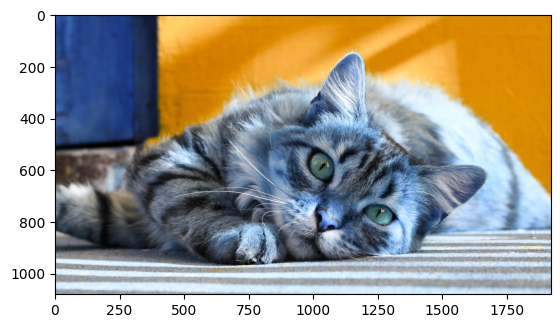

In [49]:
img = cv2.imread("/content/catanddog_train/cat.jpg")
plt.imshow(img)
img = cv2.resize(img, (100,100), interpolation=cv2.INTER_LINEAR)
img = ToTensor()(img).unsqueeze(0)
print(img.shape)

In [50]:
result = LayerActivations(model.features, 0)

model(img)
activations = result.features

/tmp/ipython-input-3667415102.py:74: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


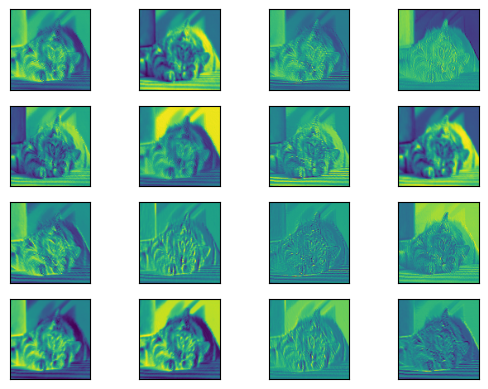

<Figure size 1200x800 with 0 Axes>

In [51]:
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12,8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0] [row*10+column])
plt.show()

In [52]:
result = LayerActivations (model.features, 20) # 20번째 Conv2d 특성 맵 확인
model(img)
activations = result.features

/tmp/ipython-input-3667415102.py:74: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


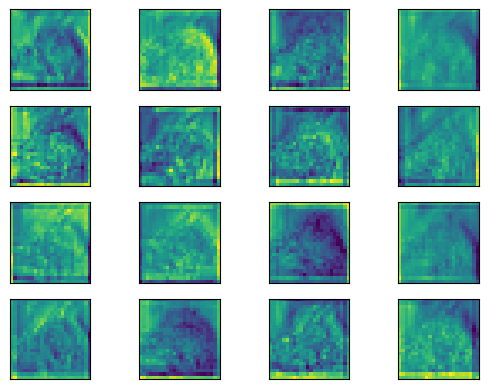

<Figure size 1200x800 with 0 Axes>

In [54]:
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12,8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()

In [55]:
result = LayerActivations(model. features, 40) # 40번째 Conv2d 특성 맵 확인
model(img)
activations = result.features

/tmp/ipython-input-3667415102.py:74: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


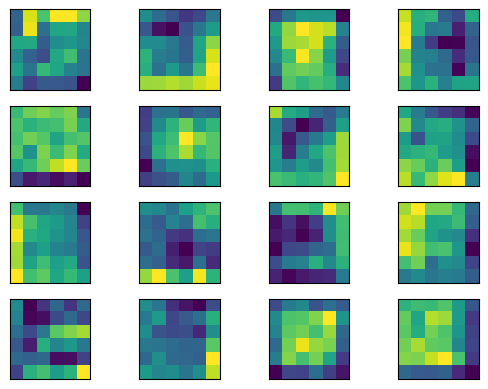

<Figure size 1200x800 with 0 Axes>

In [56]:
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12,8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()